# Channel Shift Analysis: Digital Versus Form-Based Transactions

## Introduction

This notebook explores monthly operational transaction volumes across two channels, digital and form-based, to understand how channel behavior evolves over time.  Using Lumen's decomposition, diagnostics, and structural break detection capabilities, I analyze trends, seasonality, and adoption patterns to uncover how digital usage is accelerating relative to traditional form-based processing.

The goal is to illustrate how time-series intelligence can reveal operational shifts, identify inflection points, and support forecasting for capacity planning and digital transformation initiatives.

## Executive Summary

Key findings
Structural breaks and their operational meaning
Digital adoption trajectory
Implications for staffing, capacity, digital strategy

## Project Setup

The following code ensures this notebook can import modules from the project's root directory.  It finds the project root and adds that folder to Python's module search path.  This allows the imports below to work even though the notebook is nested inside subfolders.

In [2]:
import sys
import os

# 1. Get the directory where the notebook is running
notebook_dir = os.getcwd()

# 2. Define your project root explicitly (FAST + RELIABLE)
project_root = r"g:\My Drive\Projects\lumen"

# 3. Add it to sys.path if not already present
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# 4. Confirm it worked
print("Notebook directory:", notebook_dir)
print("Project root added:", project_root)
print("sys.path[0]:", sys.path[0])


Notebook directory: g:\My Drive\Projects\lumen\notebooks\channel_analysis
Project root added: g:\My Drive\Projects\lumen
sys.path[0]: g:\My Drive\Projects\lumen


Load code modules.

In [3]:
from lumen.data_loader import DataConfig
from lumen.orchestrator import Orchestrator
from lumen.aggregator_factory import AggregatorFactory
from lumen.plotter import Plotter

## Load and Prepare the Dataset

### Data Overview

In this example, we have two .xlsx files, one for digital transactions and another for form-based transactions.  The files contain two columns, `Month` and `Value`.  

`Month` contains the month and year in `yyyy-mm` format and `Value` contains the number of transactions completed in that period.  Months range from `2023-11` through `2026-05`.

`transactions_digital.xlsx` contains a total of 76,772 transactions, and `transactions_form.xlsx` contains a total of 57,270 transactions.

### Create a DataConfig

Define how Lumen should interpret your dataset by specifiying which column contains the dates and which column contains the numeric values.  This tells Lumen how to parse, validate, and structure the time series before any decomposition or forecasting happens.

In [4]:
config = DataConfig(
    date_col="Month",
    value_col="Value"
)

### Initialize the Orchestrator

Pass the configuration into the `Orchestrator`, which becomes the main controller for running the full Lumen workflow, loading data, decomposing the series, generating diagnostics, detecting breaks, and producing forecasts.

In [5]:
orchestrator = Orchestrator(data_config = config)

### Define Mapping

Define a simple mapping between each channel name and the file that contains its data. This lets the orchestrator loop through channels automatically, loading the correct dataset for Form and Digital without hard‑coding paths later in the notebook.

In [6]:
paths = {
    "Form": "transactions_form.xlsx",
    "Digital": "transactions_digital.xlsx"
}

Import transaction volumes
Quick preview
Initial exploratory plot

### Run Forecast and Generate Payload

Run Lumen’s multi‑series forecasting workflow by passing in the file paths, specifying a 24‑month forecast horizon, and choosing a bottom‑up aggregation strategy. 

The orchestrator loads each series, decomposes it, generates diagnostics, detects structural breaks, produces forecasts, and then combines the results into a single payload object that contains:

* individual series forecasts,
* aggregated forecasts,
* diagnostics for each channel,
* break metadata, and
* histories and combined history.

This payload becomes the central result for all plots, comparisons, and narrative analysis.

In [7]:
payload = orchestrator.run_multi(
    paths = paths,
    steps = 24,
    aggregator = AggregatorFactory.create("bottom_up")
)

Create a folder for the plots.

In [8]:
plotter = Plotter(save_dir = "plots")

Loop through each series and generate the plots.

In [9]:
for work_type in payload.individual.keys():

    history = payload.metadata["history"][work_type]
    forecast = payload.individual[work_type]
    diagnostics = payload.diagnostics[work_type]
    model = payload.models[work_type]

    future_index = forecast.index if forecast is not None else None

    plotter.plot_all(
        series = history,
        model = model,
        forecast = forecast,
        future_index = future_index,
        diagnostics = diagnostics,
        prefix = work_type
    )



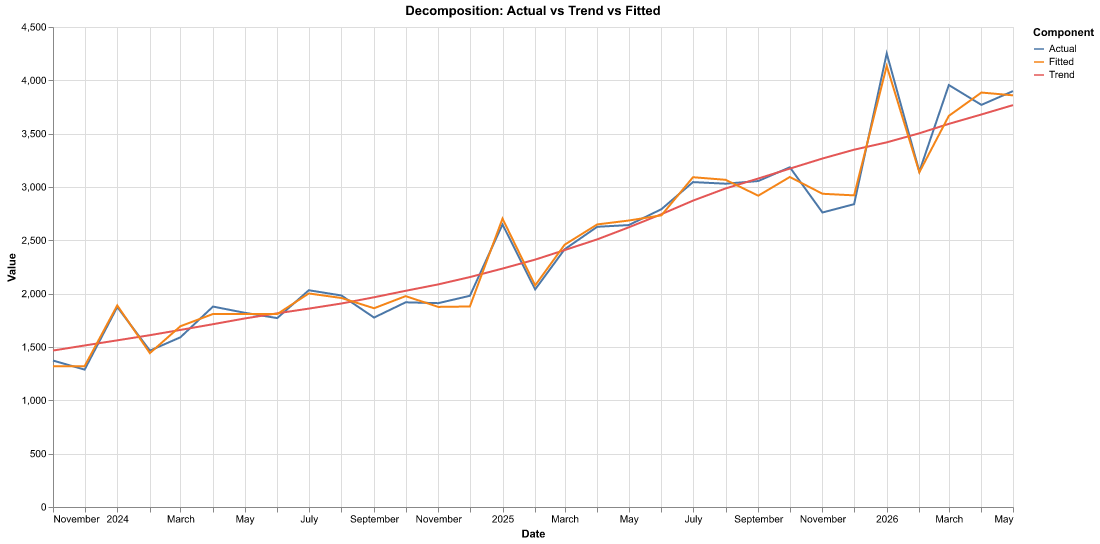

In [11]:
display(Image(filename = "plots/Digital_01_decomposition.png"))

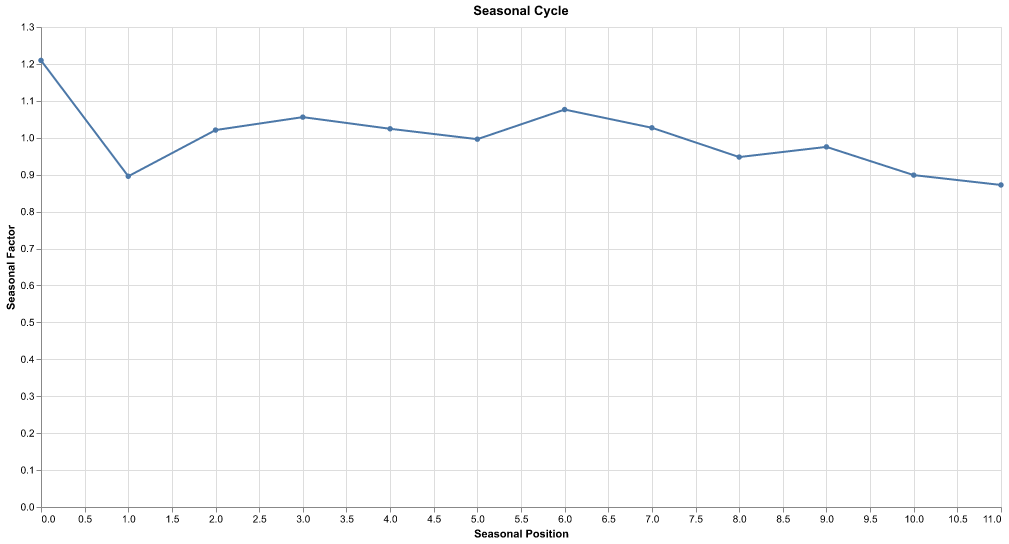

In [12]:
display(Image(filename = "plots/Digital_02_seasonal_cycle.png"))

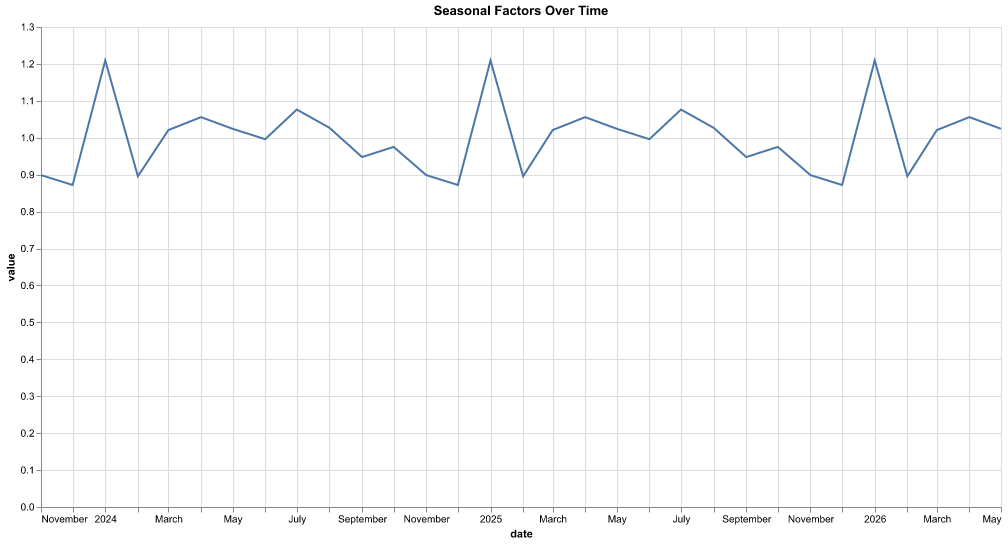

In [13]:
display(Image(filename = "plots/Digital_03_seasonal_factors_over_time.png"))

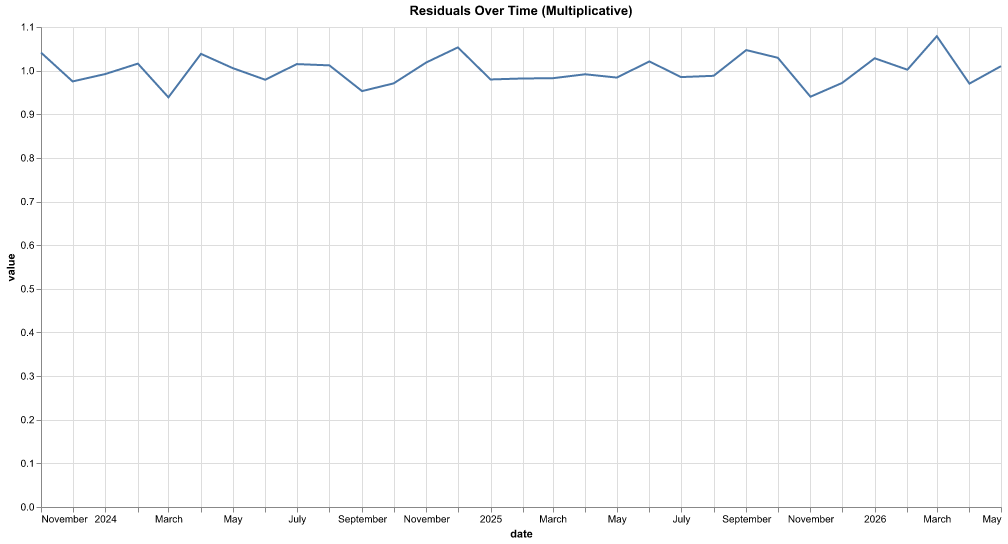

In [14]:
display(Image(filename = "plots/Digital_04_residuals.png"))

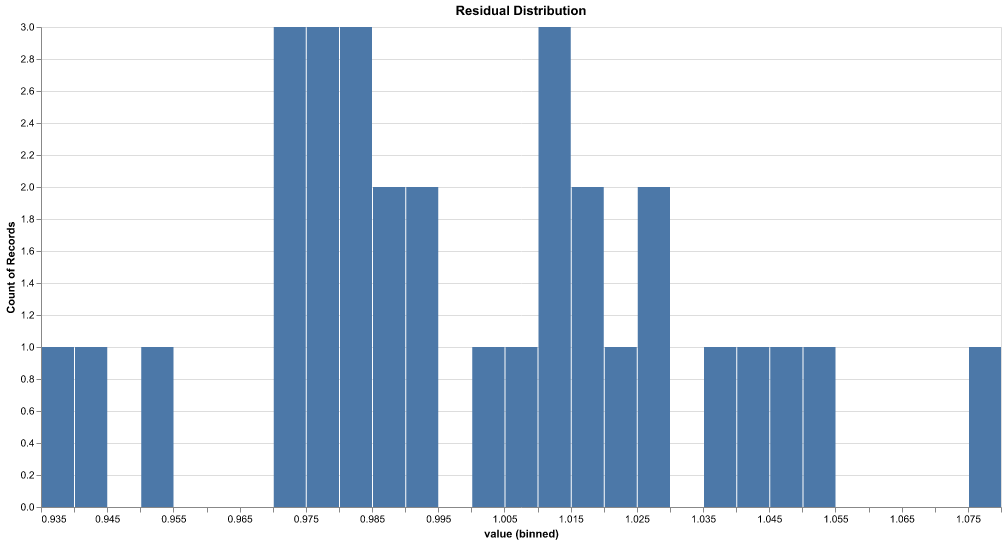

In [15]:
display(Image(filename = "plots/Digital_05_residual_distribution.png"))

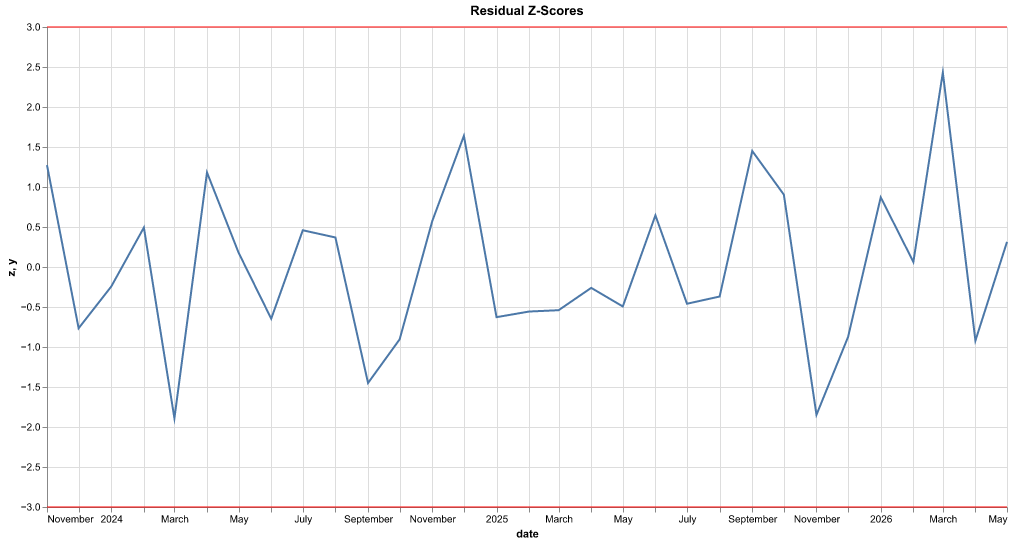

In [16]:
display(Image(filename = "plots/Digital_06_residual_zscores.png"))

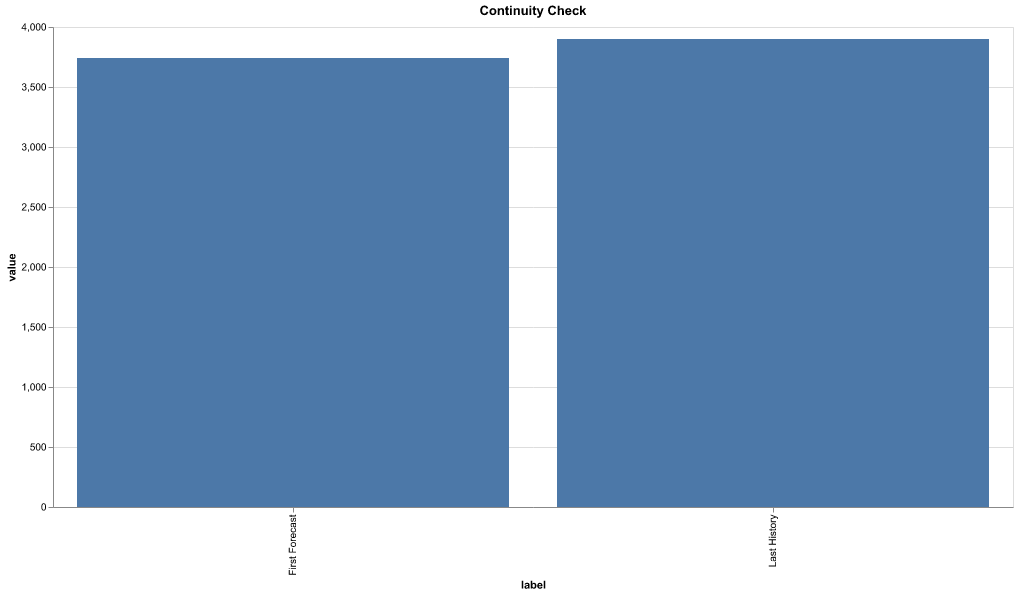

In [17]:
display(Image(filename = "plots/Digital_08_continuity.png"))

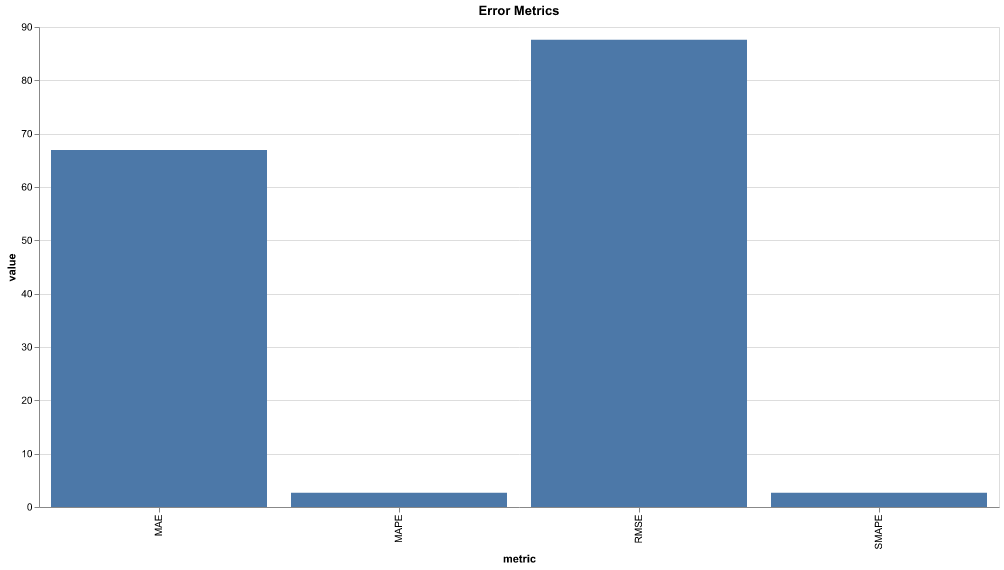

In [18]:
display(Image(filename = "plots/Digital_09_error_metrics.png"))

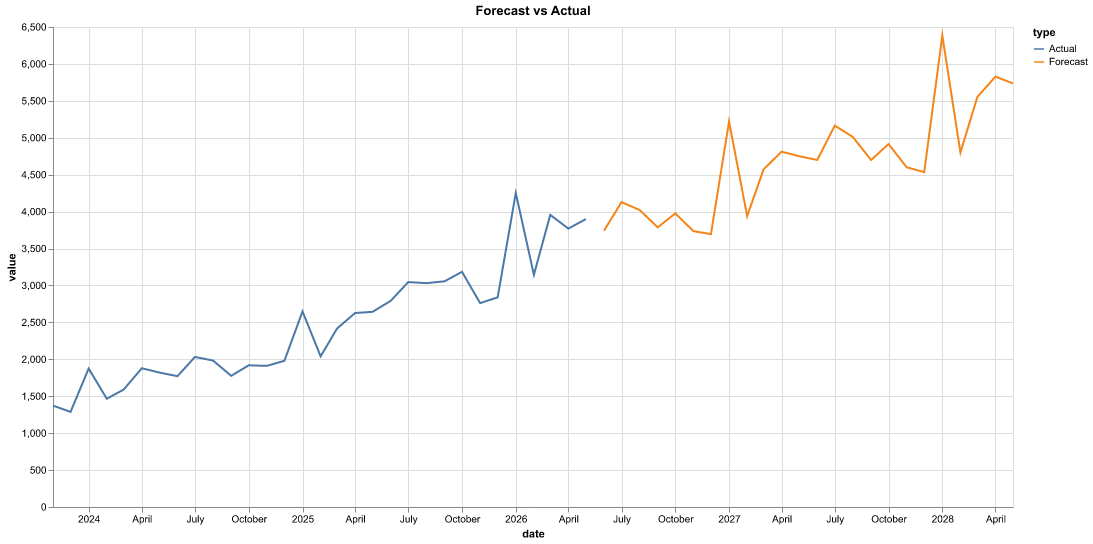

In [19]:
display(Image(filename = "plots/Digital_10_forecast_vs_actual.png"))

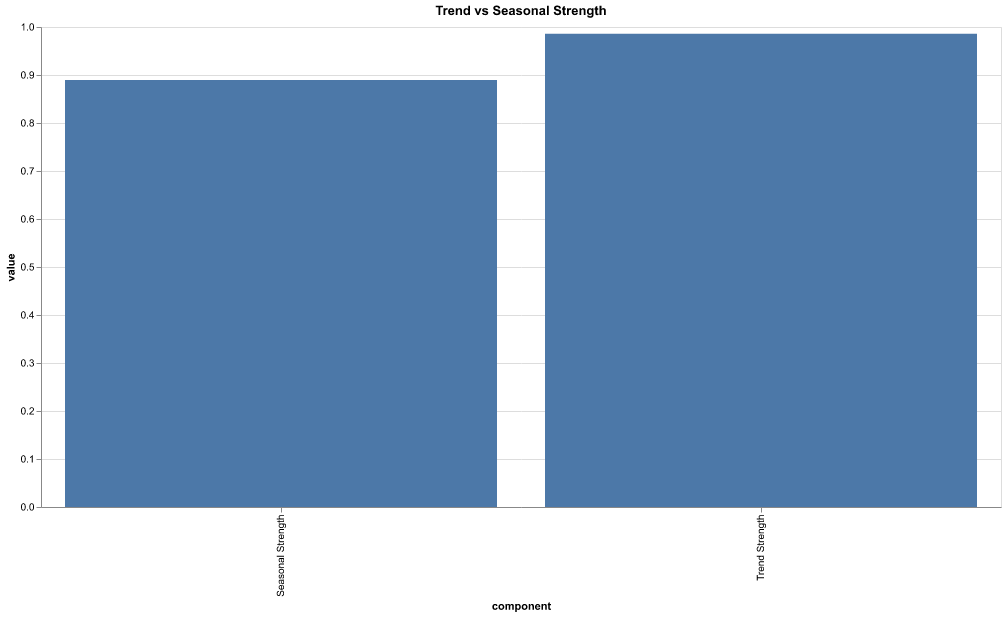

In [20]:
display(Image(filename = "plots/Digital_11_strength_bars.png"))

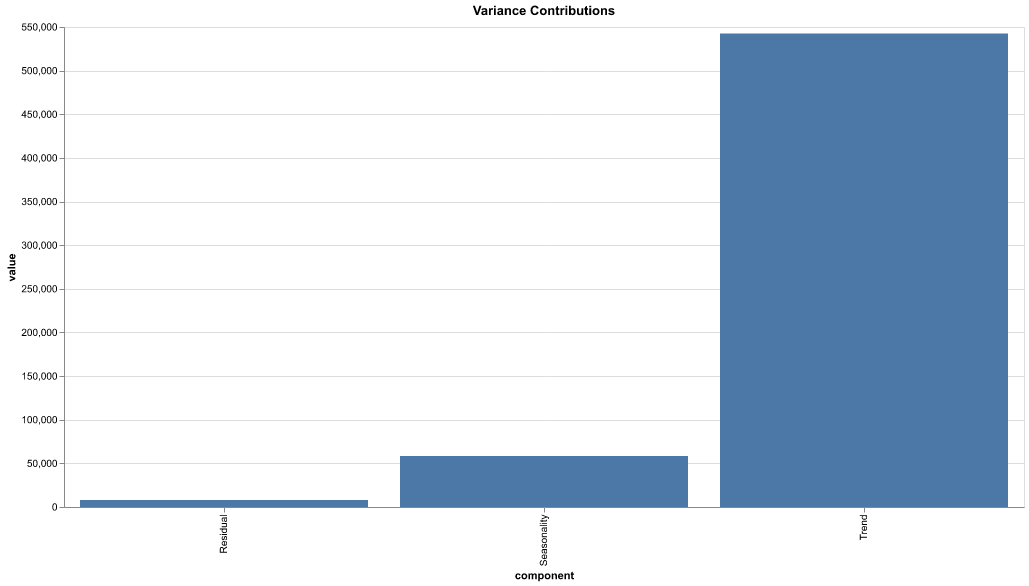

In [21]:
display(Image(filename = "plots/Digital_12_variance_contributions.png"))

Export the combined output file.

In [9]:
orchestrator.export(
    "channel_analysis_bottom_up_output.xlsx",
    payload
)

## Run Lumen on Each Channel

Decompose each series
Generate diagnostics
Detect structural breaks

## Visualize Decomposition

Trend component with break annotations
Seasonal component comparison
Remainder analysis

## Channel-Level Diagnostics

Trend strength comparison
Seasonal strength comparison
Continuity and jump analysis
Break classification

## Digital Versus Form-Based Channal Shift

Compare trend slopes
Compare seasonal patterns
Identify divergence points
Digital share over time
Crossover or widening gap analysis

## Forecasting Future Volumes

Forecast digital, form-based, and combined
Visualize forecast horizon
Discuss implications for operational planning